In [1]:
from pathlib import Path

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
# from pzo.pzo_lattice import *
# from pzo.pzo_utils import *

from metric_learning.dataset import DataWithLabels
import torch
import numpy as np
from torch.utils.data import Dataset, random_split, DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

In [ ]:
input_folder = Path('clustered_data')

dataset = DataWithLabels.from_npz(input_folder / 'data_higher.npz')
X_umap = np.load(input_folder / 'umap_higher.npy')

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels

## Contrastive Learning

In [3]:
from contrastive_learning.model import SiameseNetwork, TrainConfig, train_model, get_embeddings
from contrastive_learning.dataset import make_balanced_train_test_dataset
num_epochs = 100
warmup_epochs = max(1, int(0.05 * num_epochs))
EMBEDDING_SIZE = 2
train_loader, test_loader = make_balanced_train_test_dataset(
    Configurations, Labels, 
    batch_size=64, 
    train_ratio=0.8, 
    positive_ratio=0.5
)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train = True
save_model = True
save_dir = Path('results')
if train:
    model = SiameseNetwork(embedding_size=EMBEDDING_SIZE).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched1 = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])
    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        test_loader=test_loader,
    )

    avg_loss, avg_val_loss = train_model(config, num_epochs=num_epochs, steps_per_epoch=50, margin=1.0)
    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'siamese_encoder.pt')
else:
    checkpoint = torch.load(save_dir / 'siamese_encoder.pt', map_location=device, weights_only=True)

    model = SiameseNetwork(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")

Epoch 1/100, Average Loss: 0.415171, Average Val Loss: 0.251326
Epoch 2/100, Average Loss: 0.197199, Average Val Loss: 0.056152
Epoch 3/100, Average Loss: 0.103495, Average Val Loss: 0.050677
Epoch 4/100, Average Loss: 0.081621, Average Val Loss: 0.044662
Epoch 5/100, Average Loss: 0.068885, Average Val Loss: 0.054812
Epoch 6/100, Average Loss: 0.065302, Average Val Loss: 0.050510
Epoch 7/100, Average Loss: 0.063776, Average Val Loss: 0.051138
Epoch 8/100, Average Loss: 0.057387, Average Val Loss: 0.047294
Epoch 9/100, Average Loss: 0.055435, Average Val Loss: 0.065112
Epoch 10/100, Average Loss: 0.055046, Average Val Loss: 0.046560
Epoch 11/100, Average Loss: 0.053223, Average Val Loss: 0.048411
Epoch 12/100, Average Loss: 0.055476, Average Val Loss: 0.056334
Epoch 13/100, Average Loss: 0.055630, Average Val Loss: 0.055466
Epoch 14/100, Average Loss: 0.056072, Average Val Loss: 0.056319
Epoch 15/100, Average Loss: 0.051589, Average Val Loss: 0.043690
Epoch 16/100, Average Loss: 0.0532

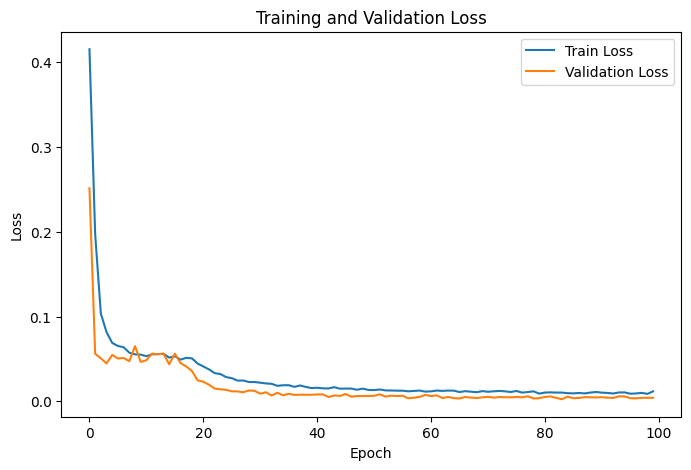

In [4]:
if train:
    plt.figure(figsize=(8, 5))
    plt.plot(avg_loss, label='Train Loss')
    plt.plot(avg_val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()


***

## Clustering

here, we shall cluster samples in the embedding space and compare to the original clustering.

C:\Users\Vít\AppData\Local\Temp\ipykernel_22144\2460606634.py:19: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels2, palette=list(PALETTE), alpha=0.7, ax=axs[1])


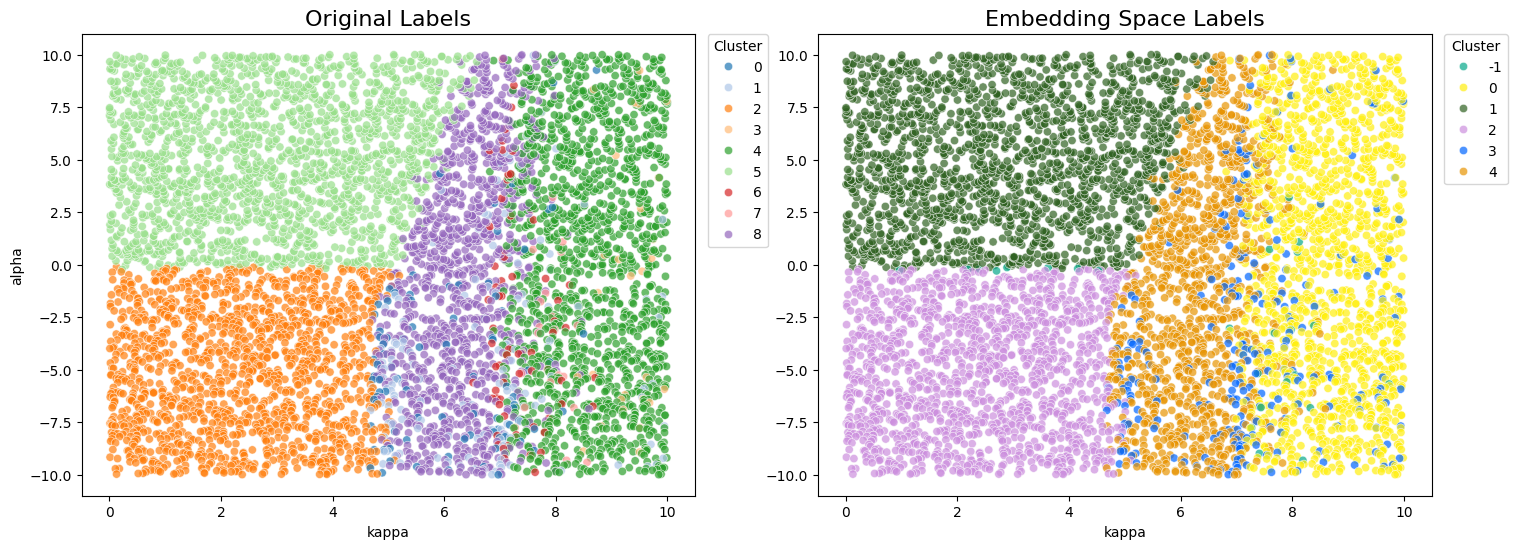

In [6]:
# Compare original labels and new labels in the phase diagram
from common.theme import PALETTE
import importlib
from hdbscan import HDBSCAN

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

hd2 = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.02, cluster_selection_method='eom').fit(all_embeddings)
Labels2 = hd2.labels_


sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels, palette='tab20', alpha=0.7, ax=axs[0])
axs[0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axs[0].set_xlabel('kappa')
axs[0].set_ylabel('alpha')
axs[0].set_title('Original Labels', size=16)   
fig.subplots_adjust(right=0.8)

sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels2, palette=list(PALETTE), alpha=0.7, ax=axs[1])
axs[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axs[1].set_xlabel('kappa')
# axs[1].set_ylabel('alpha')
axs[1].set_title('Embedding Space Labels', size=16)
fig.subplots_adjust(right=0.8)

plt.show()

In [7]:
from metric_learning.utils import plot_2d_arrows_stratified, plot_3d_arrows_stratified
from metric_learning import utils
from importlib import reload
dim = all_embeddings.shape[-1]

if dim == 2:
    fig = plot_2d_arrows_stratified(all_embeddings, Labels2, samples_per_cluster=1000)
    fig.show()
elif dim == 3:
    fig = plot_3d_arrows_stratified(all_embeddings, Labels2, samples_per_cluster=1000)
    fig.show()

In [8]:
# from sklearn.metrics import pairwise_distances
# def rotate_coordinates(config0):
#     P0 = config0[..., :2]
#     A0 = config0[..., 2:]
#     sqrt2 = np.sqrt(2.)
#     R, S = P0[..., 0], P0[..., 1]
#     V, U = (S + R) / sqrt2, (S - R) / sqrt2
#     Phi, Psi = A0[..., 0], A0[..., 1]
#     Xi, Eta = (Psi + Phi) / sqrt2, (Psi - Phi) / sqrt2
#     P = np.stack([U, V], axis=-1)
#     A = np.stack([Eta, Xi], axis=-1)
#     return np.dstack([P, A])


# n_configs = 1
# save_init_conf = Path('init_conf') / 'siamese'
# chosen_configs = []
# equiv_labels = []
# unique_lab = np.unique(Labels2)
# for label in unique_lab:
#     if label == -1:
#         continue
#     idxs = (Labels2 == label)
#     global_position = np.arange(len(Labels2))[idxs]
#     mean_dist = np.mean(pairwise_distances(all_embeddings[idxs]), axis=0)
#     sorted_id = np.argsort(mean_dist)
#     glob_id = global_position[sorted_id[:n_configs]]
#     rotated_confs = np.array([rotate_coordinates(c) for c in Configurations[glob_id]])
#     chosen_configs.append(rotated_confs)
#     equiv_labels.append([label]*n_configs)

# chosen_configs = np.array(chosen_configs)
# chosen_configs = chosen_configs.reshape((n_configs*(len(unique_lab)-1), 8, 8, 4))
# equiv_labels = np.array(equiv_labels).flatten()


# save_init_dir = Path('init_conf') / 'siamese'
# for co, la in zip(chosen_configs, equiv_labels):
#     np.save(save_init_dir / f'init_{la}', co)


# save_init_conf = Path('init_conf') / 'siamese'
# configs_test = []
# for f in save_init_conf.iterdir():
#     configs_test.append(rotate_coordinates(np.load(f)))


# DataWithLabels(np.array(configs_test)).plot(0)


In [9]:
# Polarization and hidden field in pseudo-cubic coordinates
GradFile = np.load('ConfigsSiamese.npz')
configs = GradFile['configs']
alpha_kappa = GradFile['values']
energies = GradFile['energies']


embeddings_opt = get_embeddings(config, configs)



    'data': [{'customdata': {'bdata': ('8hbIMtsCvBsjROAOIgsoAkcVIwQ3RQ' ... 'ytS…

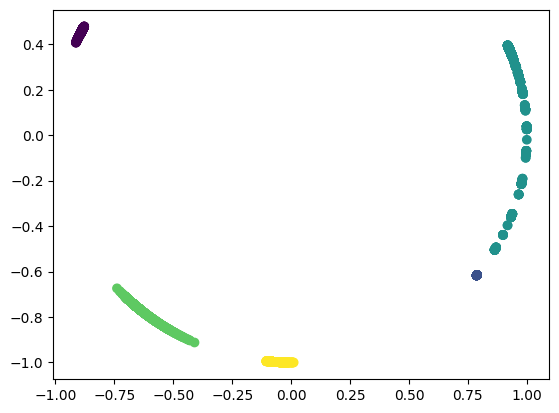

In [10]:
hd2 = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.1, cluster_selection_method='eom').fit(embeddings_opt)
Labels2_grad = hd2.labels_
plt.scatter(embeddings_opt[:,0], embeddings_opt[:, 1], c=Labels2_grad)
import importlib
from metric_learning.utils import InteractivePhaseDiagram

dataset = DataWithLabels(
    configs,
    alpha_kappa, None, energies, Labels2_grad
)


InteractivePhaseDiagram(dataset).show()

In [14]:
# dataset.augument_randomly(ratio = 1.0, repetition=True)

Values_opt         = alpha_kappa
Configurations_opt = configs
Energies_opt       = energies
X_opt             = np.empty_like(Labels2_grad)

embeddings_grad = embeddings_opt


data_w_new_labels_grad = DataWithLabels(
    configs, alpha_kappa, X_opt, energies,Labels2_grad
)

In [15]:
# save learned for graphing
save = True
if save:
    dir = Path('results')
    dir.mkdir(exist_ok=True)
    np.save(dir / 'embeddings_siamese.npy', all_embeddings)
    np.save(dir / 'embeddings_grad_siamese.npy', embeddings_grad)

    data_w_new_labels = DataWithLabels(
        Configurations,
        Values,
        X,
        Energies,
        Labels2 ,
    )

    data_w_new_labels.to_npz(dir / 'configs_siamese.npz')
    data_w_new_labels_grad.to_npz(dir / 'configs_grad_siamese.npz')
    np.save(dir / 'labels', Labels)